# NASA Exoplanet Archive — Data Explorer
### A Python + SQL analysis of confirmed exoplanet data
**Author:** Emma Follis  
**Data source:** [NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu)  
**Last updated:** June 2026

---

## Overview
This notebook explores the NASA Exoplanet Archive's confirmed planets table (6,298 planets, 84 columns)
using Python and SQL. The analysis covers discovery methods, historical trends, and planet size
distributions — key demographic questions in modern exoplanet science.

---


## Setup
### Importing libraries

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

### Loading the data

In [3]:
# Load the CSV file into a pandas DataFrame
df = pd.read_csv('PS_CompPars.csv', comment='#', low_memory=False)

# Preview the first 5 rows
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (6298, 84)


,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_controv_flag,pl_orbper,pl_orbpererr1,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,11 Com b,11 Com,2,1,Radial Velocity,2007.0,Xinglong Station,0,323.21000,0.06,...,-1.9238,4.72307,0.023,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848
1,11 UMi b,11 UMi,1,1,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,0,516.21997,3.20,...,-1.9765,5.01300,0.005,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903
2,14 And b,14 And,1,1,Radial Velocity,2008.0,Okayama Astrophysical Observatory,0,186.76000,0.11,...,-0.7140,5.23133,0.023,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826
3,14 Her b,14 Her,1,2,Radial Velocity,2002.0,W. M. Keck Observatory,0,1766.41000,0.67,...,-0.0073,6.61935,0.023,-0.023,4.714,0.016,-0.016,6.38300,0.000351,-0.000351
4,16 Cyg B b,16 Cyg B,3,1,Radial Velocity,1996.0,Multiple Observatories,0,798.50000,1.00,...,-0.0111,6.21500,0.016,-0.016,4.651,0.016,-0.016,6.06428,0.000603,-0.000603


## Data Exploration
### Examining the dataset structure

In [4]:
# See all column names
print("All columns:")
print(df.columns.tolist())

All columns:
['pl_name', 'hostname', 'sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year', 'disc_facility', 'pl_controv_flag', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_spectype', 'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2', 'st_masslim', 'st_met', 'st_meterr1', 'st_meterr2', 'st_metlim', 'st_metratio', 'st_logg', 'st_loggerr1', 'st_loggerr2', 'st_logglim', '

### Checking data quality
Not every planet has every measurement — understanding completeness before
analysis is essential to interpreting results accurately.

In [5]:
# Check how complete our key columns are
key_columns = [
    'pl_name', 'discoverymethod', 'disc_year',
    'pl_orbper', 'pl_rade', 'pl_bmasse',
    'pl_eqt', 'pl_insol', 'st_spectype', 'sy_dist'
]

# Calculate percentage of non-missing values for each column
completeness = df[key_columns].notna().mean() * 100

print("Data completeness for key columns (% with values):")
print(completeness.round(1))

Data completeness for key columns (% with values):
pl_name            100.0
discoverymethod    100.0
disc_year          100.0
pl_orbper           94.6
pl_rade             99.2
pl_bmasse           99.5
pl_eqt              91.7
pl_insol            90.9
st_spectype         37.0
sy_dist             99.6
dtype: float64


### Building the SQL database
Loading the DataFrame into SQLite to enable SQL querying alongside pandas.

In [6]:
# Create a SQLite database in memory
conn = sqlite3.connect(':memory:')

# Load our DataFrame into the database as a table called 'exoplanets'
df.to_sql('exoplanets', conn, if_exists='replace', index=False)

print("Database created successfully!")
print(f"Table 'exoplanets' loaded with {len(df)} rows and {len(df.columns)} columns.")

Database created successfully!
Table 'exoplanets' loaded with 6298 rows and 84 columns.


## Query 1: Discovery Methods
### How were these 6,298 planets found?
Eleven different detection methods have been used to confirm exoplanets.
The distribution reflects both the physics of each method and the telescopes
humanity has built to use them.

In [7]:
# Query 1: How many planets were discovered by each method?
query1 = """
SELECT
    discoverymethod,
    COUNT(*) as total_planets,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM exoplanets), 1) as percentage
FROM exoplanets
GROUP BY discoverymethod
ORDER BY total_planets DESC;
"""

result1 = pd.read_sql_query(query1, conn)
print("Planets discovered by each method:")
print(result1)

Planets discovered by each method:
                  discoverymethod  total_planets  percentage
0                         Transit           4653        73.9
1                 Radial Velocity           1186        18.8
2                    Microlensing            278         4.4
3                         Imaging             97         1.5
4       Transit Timing Variations             41         0.7
5       Eclipse Timing Variations             17         0.3
6   Orbital Brightness Modulation              9         0.1
7                   Pulsar Timing              8         0.1
8                      Astrometry              6         0.1
9     Pulsation Timing Variations              2         0.0
10                Disk Kinematics              1         0.0


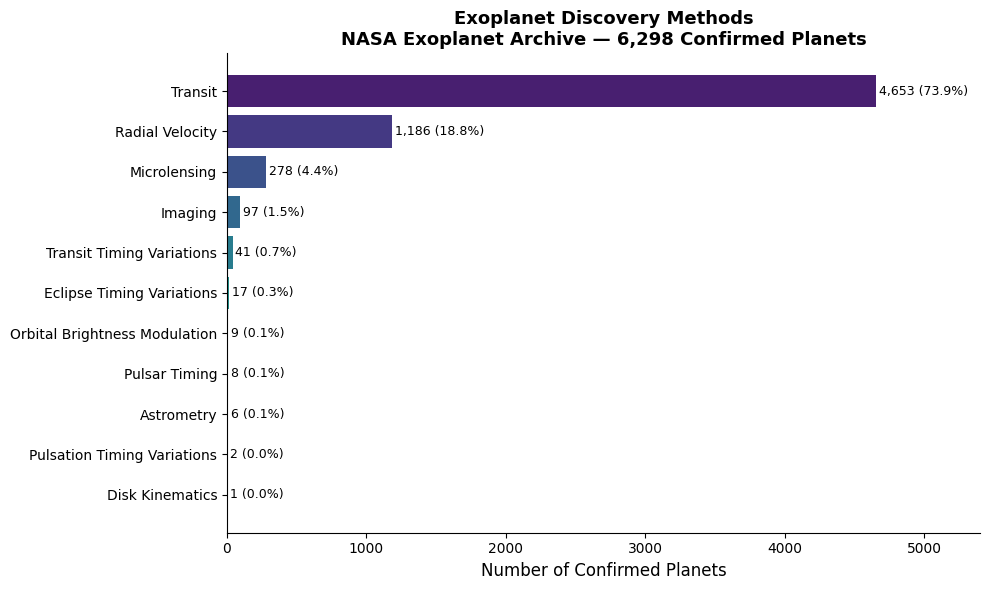

Chart saved as discovery_methods.png


In [8]:
# Visualize discovery methods
fig, ax = plt.subplots(figsize=(10, 6))

# Create a horizontal bar chart
bars = ax.barh(
    result1['discoverymethod'],
    result1['total_planets'],
    color=sns.color_palette('viridis', len(result1))
)

# Add value labels on each bar
for bar, (total, pct) in zip(bars, zip(result1['total_planets'], result1['percentage'])):
    ax.text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height()/2,
        f'{total:,} ({pct}%)',
        va='center', fontsize=9
    )

# Labels and formatting
ax.set_xlabel('Number of Confirmed Planets', fontsize=12)
ax.set_title('Exoplanet Discovery Methods\nNASA Exoplanet Archive — 6,298 Confirmed Planets',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, 5400)
sns.despine()

plt.tight_layout()
plt.savefig('discovery_methods.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as discovery_methods.png")

## Query 2: Discovery Timeline
### How has the rate of exoplanet discovery changed over time?
The history of exoplanet discovery is not a smooth curve — it reflects specific
mission launches, bulk confirmation events, and technological leaps. Understanding
this context is essential for interpreting the numbers.

In [9]:
# Query 2: How many planets were discovered each year?
query2 = """
SELECT
    disc_year,
    COUNT(*) as planets_discovered,
    discoverymethod as dominant_method
FROM exoplanets
WHERE disc_year IS NOT NULL
GROUP BY disc_year
ORDER BY disc_year ASC;
"""

result2 = pd.read_sql_query(query2, conn)
print(result2)

    disc_year  planets_discovered  dominant_method
0      1992.0                   2    Pulsar Timing
1      1994.0                   1    Pulsar Timing
2      1995.0                   1  Radial Velocity
3      1996.0                   6  Radial Velocity
4      1997.0                   1  Radial Velocity
5      1998.0                   6  Radial Velocity
6      1999.0                  13  Radial Velocity
7      2000.0                  16  Radial Velocity
8      2001.0                  12  Radial Velocity
9      2002.0                  29  Radial Velocity
10     2003.0                  22  Radial Velocity
11     2004.0                  27          Imaging
12     2005.0                  36          Imaging
13     2006.0                  32  Radial Velocity
14     2007.0                  52  Radial Velocity
15     2008.0                  63  Radial Velocity
16     2009.0                  94  Radial Velocity
17     2010.0                  92  Radial Velocity
18     2011.0                 1

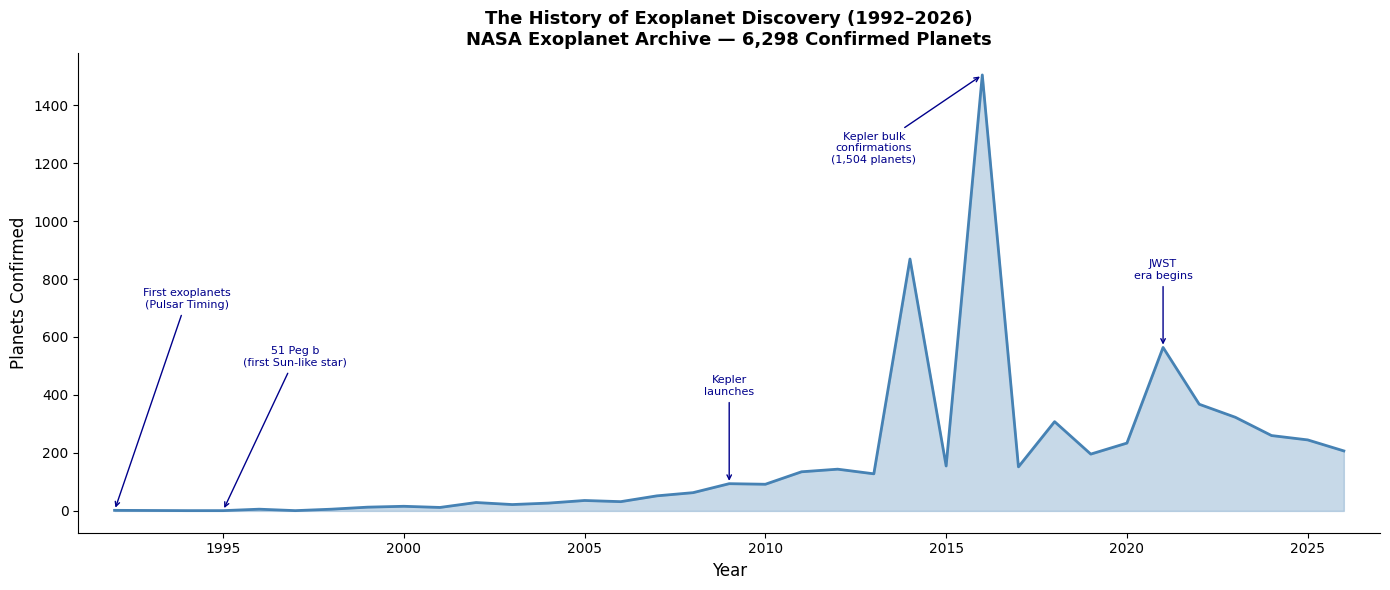

Chart saved as discovery_timeline.png


In [15]:
# Visualize planet discoveries over time
fig, ax = plt.subplots(figsize=(14, 6))

# Create the line with filled area underneath
ax.fill_between(
    result2['disc_year'],
    result2['planets_discovered'],
    alpha=0.3,
    color='steelblue'
)
ax.plot(
    result2['disc_year'],
    result2['planets_discovered'],
    color='steelblue',
    linewidth=2
)

# Annotate key moments in exoplanet history
annotations = {
    1992: ('First exoplanets\n(Pulsar Timing)', 1994, 700),
    1995: ('51 Peg b\n(first Sun-like star)', 1997, 500),
    2009: ('Kepler\nlaunches', 2009, 400),
    2016: ('Kepler bulk\nconfirmations\n(1,504 planets)', 2013, 1200),
    2021: ('JWST\nera begins', 2021, 800),
}

for year, (label, text_x, text_y) in annotations.items():
    y_val = result2.loc[result2['disc_year'] == year, 'planets_discovered'].values
    if len(y_val) > 0:
        ax.annotate(
            label,
            xy=(year, y_val[0]),
            xytext=(text_x, text_y),
            fontsize=8,
            color='darkblue',
            ha='center',
            arrowprops=dict(arrowstyle='->', color='darkblue', lw=1)
        )

# Formatting
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Planets Confirmed', fontsize=12)
ax.set_title('The History of Exoplanet Discovery (1992–2026)\nNASA Exoplanet Archive — 6,298 Confirmed Planets',
             fontsize=13, fontweight='bold')
ax.set_xlim(1991, 2027)
sns.despine()

plt.tight_layout()
plt.savefig('discovery_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as discovery_timeline.png")

## Query 3: Planet Size Distribution
### What sizes of planets have we actually found?
Rocky Earth-sized planets (< 1.25 Earth radii) are the hardest to detect and
the primary targets for JWST atmospheric characterization. This query examines
how the confirmed planet population breaks down by size class.

In [16]:
# Query 3: Distribution of planet sizes
query3 = """
SELECT
    pl_name,
    pl_rade,
    CASE
        WHEN pl_rade < 1.25 THEN '1. Earth-sized (< 1.25 Re)'
        WHEN pl_rade < 2.0 THEN '2. Super-Earth (1.25–2.0 Re)'
        WHEN pl_rade < 4.0 THEN '3. Sub-Neptune (2.0–4.0 Re)'
        WHEN pl_rade < 10.0 THEN '4. Neptune-sized (4.0–10.0 Re)'
        ELSE '5. Jupiter-sized (> 10.0 Re)'
    END as size_class
FROM exoplanets
WHERE pl_rade IS NOT NULL
ORDER BY pl_rade ASC;
"""

result3 = pd.read_sql_query(query3, conn)

# Count each size class
size_counts = result3['size_class'].value_counts().sort_index()
print("Planet size distribution:")
print(size_counts)

Planet size distribution:
size_class
1. Earth-sized (< 1.25 Re)         576
2. Super-Earth (1.25–2.0 Re)      1196
3. Sub-Neptune (2.0–4.0 Re)       2076
4. Neptune-sized (4.0–10.0 Re)     603
5. Jupiter-sized (> 10.0 Re)      1797
Name: count, dtype: int64


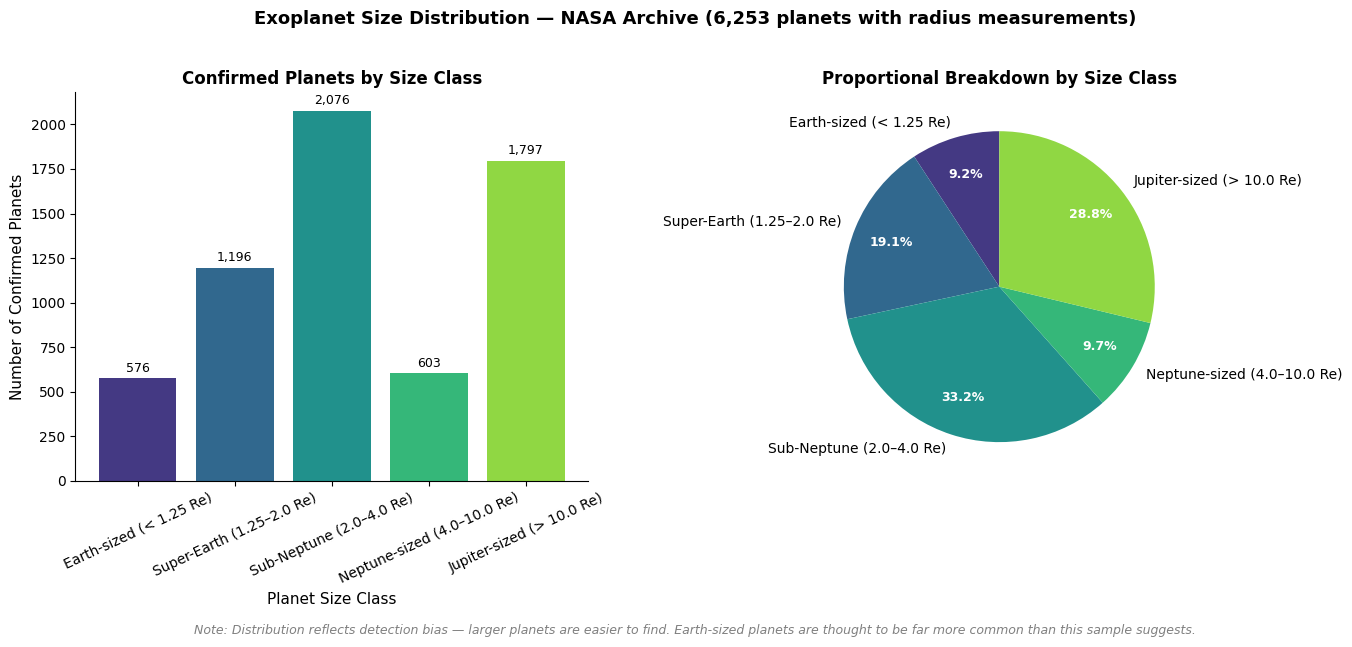

Chart saved as size_distribution.png


In [17]:
# Visualize planet size distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Clean labels for display (remove the number prefixes)
clean_labels = [label.split('. ')[1] for label in size_counts.index]
colors = sns.color_palette('viridis', len(size_counts))

# Left chart: bar chart
bars = ax1.bar(clean_labels, size_counts.values, color=colors)

# Add value labels on top of each bar
for bar, val in zip(bars, size_counts.values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{val:,}',
        ha='center', va='bottom', fontsize=9
    )

ax1.set_xlabel('Planet Size Class', fontsize=11)
ax1.set_ylabel('Number of Confirmed Planets', fontsize=11)
ax1.set_title('Confirmed Planets by Size Class', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=25)
sns.despine(ax=ax1)

# Right chart: pie chart
wedges, texts, autotexts = ax2.pie(
    size_counts.values,
    labels=clean_labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75
)

# Make percentage text more readable
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax2.set_title('Proportional Breakdown by Size Class', fontsize=12, fontweight='bold')

# Add a note about detection bias
fig.text(
    0.5, -0.02,
    'Note: Distribution reflects detection bias — larger planets are easier to find. '
    'Earth-sized planets are thought to be far more common than this sample suggests.',
    ha='center', fontsize=9, style='italic', color='gray'
)

plt.suptitle('Exoplanet Size Distribution — NASA Archive (6,253 planets with radius measurements)',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as size_distribution.png")

## Query 4: Habitable Zone Candidates
### Which confirmed planets might support liquid water on their surface?
The habitable zone is the range of orbital distances where liquid water could
exist on a planet's surface — neither too hot nor too cold. We use two filters:
insolation flux (stellar energy received relative to Earth) and planet radius
(to select rocky candidates). This is the population JWST is now beginning to
characterize atmospherically.

In [18]:
# Query 4: Habitable zone rocky planet candidates
query4 = """
SELECT
    pl_name,
    hostname,
    st_spectype,
    pl_rade,
    pl_orbper,
    pl_eqt,
    pl_insol,
    sy_dist,
    disc_year,
    discoverymethod
FROM exoplanets
WHERE
    pl_insol BETWEEN 0.2 AND 1.8
    AND pl_rade < 2.0
    AND pl_insol IS NOT NULL
    AND pl_rade IS NOT NULL
ORDER BY pl_rade ASC;
"""

result4 = pd.read_sql_query(query4, conn)

print(f"Habitable zone rocky planet candidates: {len(result4)}")
print(f"\nSize range: {result4['pl_rade'].min():.2f} to {result4['pl_rade'].max():.2f} Earth radii")
print(f"Distance range: {result4['sy_dist'].min():.1f} to {result4['sy_dist'].max():.1f} parsecs")
print(f"\nFirst 10 candidates by size:")
print(result4[['pl_name', 'hostname', 'pl_rade', 'pl_insol', 'pl_eqt', 'sy_dist']].head(10))

Habitable zone rocky planet candidates: 58

Size range: 0.79 to 1.93 Earth radii
Distance range: 1.3 to 551.7 parsecs

First 10 candidates by size:
              pl_name          hostname  pl_rade  pl_insol  pl_eqt    sy_dist
0        TRAPPIST-1 d        TRAPPIST-1    0.788     1.115   286.2  12.429889
1        Kepler-138 e        Kepler-138    0.797     1.730   292.0  66.862400
2        TRAPPIST-1 e        TRAPPIST-1    0.920     0.646   249.7  12.429889
3         Gliese 12 b         Gliese 12    0.930     1.620   314.6  12.210000
4           TOI-700 e           TOI-700    0.953     1.270   272.9  31.126500
5       Proxima Cen b       Proxima Cen    1.020     0.641   218.0   1.301190
6  Teegarden's Star c  Teegarden's Star    1.020     0.350   209.0   3.830780
7           GJ 1002 b           GJ 1002    1.030     0.670   230.9   4.848670
8        TRAPPIST-1 f        TRAPPIST-1    1.045     0.373   217.7  12.429889
9  Teegarden's Star b  Teegarden's Star    1.050     1.080   277.0   3.8

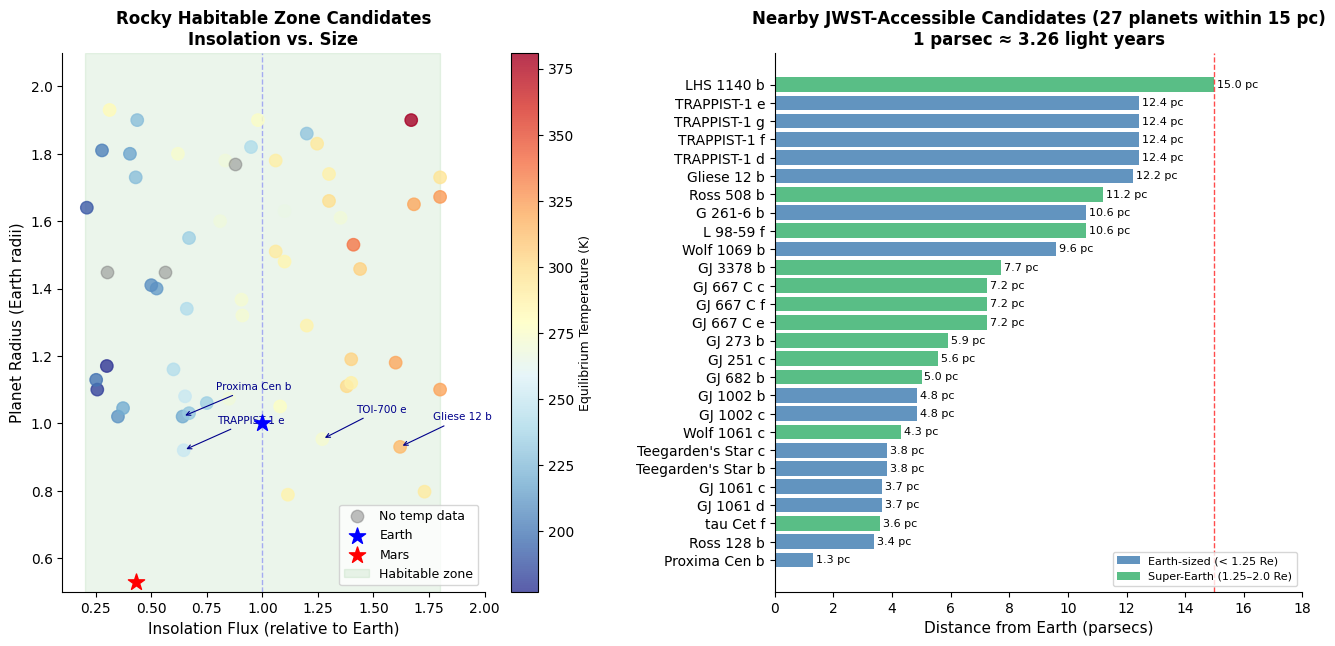

Chart saved as habitable_zone_candidates.png


In [21]:
# Visualize habitable zone candidates
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
plt.subplots_adjust(wspace=0.35)

# --- Left chart: Insolation vs Radius scatter plot ---

# Color points by equilibrium temperature where available
has_temp = result4['pl_eqt'].notna()

scatter = ax1.scatter(
    result4.loc[has_temp, 'pl_insol'],
    result4.loc[has_temp, 'pl_rade'],
    c=result4.loc[has_temp, 'pl_eqt'],
    cmap='RdYlBu_r',
    s=80,
    alpha=0.8,
    zorder=3,
    label='_nolegend_'
)

# Plot points without temperature data in gray
ax1.scatter(
    result4.loc[~has_temp, 'pl_insol'],
    result4.loc[~has_temp, 'pl_rade'],
    color='gray',
    s=80,
    alpha=0.5,
    zorder=3,
    label='No temp data'
)

# Add colorbar for temperature
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Equilibrium Temperature (K)', fontsize=9)

# Mark Earth and Mars for reference
ax1.scatter(1.0, 1.0, color='blue', s=150, zorder=5, marker='*', label='Earth')
ax1.scatter(0.43, 0.53, color='red', s=150, zorder=5, marker='*', label='Mars')

# Shade the habitable zone
ax1.axvspan(0.2, 1.8, alpha=0.08, color='green', label='Habitable zone')
ax1.axvline(x=1.0, color='blue', linestyle='--', alpha=0.3, linewidth=1)

# Annotate key planets
key_planets = {
    'TRAPPIST-1 e': (0.646, 0.920),
    'Proxima Cen b': (0.641, 1.020),
    'TOI-700 e': (1.270, 0.953),
    'Gliese 12 b': (1.620, 0.930),
}

for name, (insol, rade) in key_planets.items():
    ax1.annotate(
        name,
        xy=(insol, rade),
        xytext=(insol + 0.15, rade + 0.08),
        fontsize=7.5,
        color='darkblue',
        arrowprops=dict(arrowstyle='->', color='darkblue', lw=0.8)
    )

ax1.set_xlabel('Insolation Flux (relative to Earth)', fontsize=11)
ax1.set_ylabel('Planet Radius (Earth radii)', fontsize=11)
ax1.set_title('Rocky Habitable Zone Candidates\nInsolation vs. Size',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_xlim(0.1, 2.0)
ax1.set_ylim(0.5, 2.1)
sns.despine(ax=ax1)

# --- Right chart: Nearby JWST-accessible candidates only ---
nearby = result4[result4['sy_dist'] <= 15].sort_values('sy_dist')

colors_nearby = [
    'steelblue' if r < 1.25 else 'mediumseagreen'
    for r in nearby['pl_rade']
]

bars = ax2.barh(
    nearby['pl_name'],
    nearby['sy_dist'],
    color=colors_nearby,
    alpha=0.85
)

# Add distance labels on each bar
for bar, dist in zip(bars, nearby['sy_dist']):
    ax2.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{dist:.1f} pc',
        va='center', fontsize=8
    )

# Legend for color coding
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', alpha=0.85, label='Earth-sized (< 1.25 Re)'),
    Patch(facecolor='mediumseagreen', alpha=0.85, label='Super-Earth (1.25–2.0 Re)')
]
ax2.legend(handles=legend_elements, fontsize=8, loc='lower right')

ax2.axvline(x=15, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax2.set_xlabel('Distance from Earth (parsecs)', fontsize=11)
ax2.set_title(
    f'Nearby JWST-Accessible Candidates ({len(nearby)} planets within 15 pc)\n'
    '1 parsec ≈ 3.26 light years',
    fontsize=12, fontweight='bold'
)
ax2.set_xlim(0, 18)
sns.despine(ax=ax2)
plt.savefig('habitable_zone_candidates.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as habitable_zone_candidates.png")